### Import Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

import NeuralNetwork as NN

I0000 00:00:1780348428.873162   36120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780348428.873605   36120 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780348428.912405   36120 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780348429.906859   36120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### Define Constants

In [2]:
EPOCHS = 100
NUM_INPUTS = 10
NUM_OUTPUTS = 28 * 28
LEARNING_RATE = 0.5

### Load in Training and Test Data

In [3]:
# Get the MNIST training and testing data and labels
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# Convert train_data and test_data into 784 element vectors instead of 28x28 matrices
train_x = np.reshape(train_x, (train_x.shape[0], train_x.shape[1] * train_x.shape[2], 1)).astype(np.float32)
test_x = np.reshape(test_x, (test_x.shape[0], test_x.shape[1] * test_x.shape[2], 1)).astype(np.float32)

# Convert both sets of labels to one-hot-encoded vectors
train_y = np.eye(NUM_INPUTS)[train_y]
test_y = np.eye(NUM_INPUTS)[test_y]

# Normalize data to be in the range [0.0, 1.0]
train_x /= 255.0
test_x /= 255.0

### Create the Model

In [18]:
network = NN.NeuralNetwork(NUM_INPUTS)
network.addLayer(256, "sigmoid")
network.addLayer(NUM_OUTPUTS, "sigmoid")

### Train the Model

In [35]:

for epoch in range(EPOCHS):
    print(f"Starting epoch: {epoch}")

    mse = 0
    for i, input in enumerate(train_y):
        output = network.forwardPropagation(np.array(input).reshape(NUM_INPUTS, 1))
        mse += np.sum(output - train_x[i])**2
        network.backwardPropagation(output, train_x[i])

    print(mse)


Starting epoch: 0
43086547.90672079
Starting epoch: 1
43132381.503048025
Starting epoch: 2
43174534.64365639
Starting epoch: 3
43215996.38043481
Starting epoch: 4
43256611.102722645
Starting epoch: 5


KeyboardInterrupt: 

### Test the Model

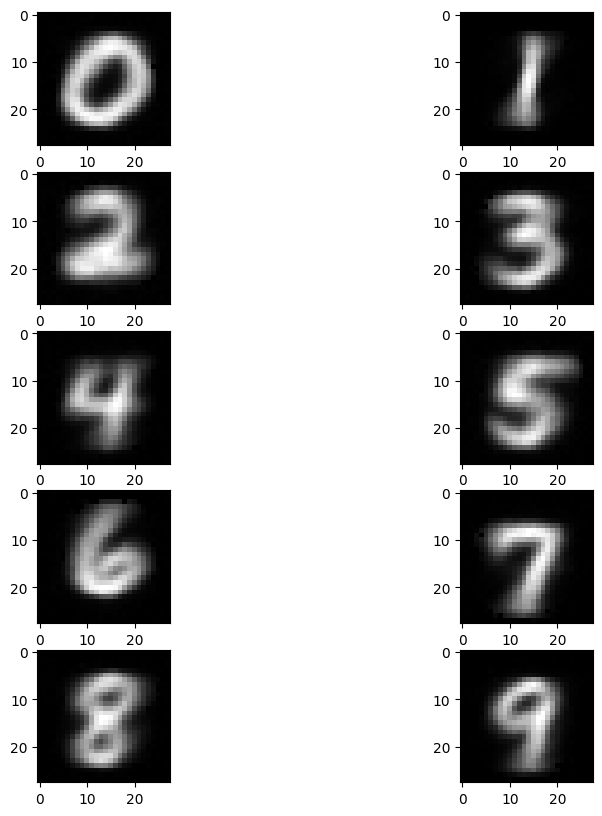

In [40]:
figure, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 10))
flattened_axes = axes.flatten()

for i, axes in enumerate(flattened_axes):
    input = np.eye(NUM_INPUTS)[i]
    output = network.forwardPropagation(input)
    output = np.reshape(output, (28, 28))
    output *= 255

    axes.imshow(output, cmap='gray')

plt.savefig('reverse_mnist.png', bbox_inches='tight', dpi=300)
plt.show()